# Satellite-Central Cross-Correlation Example

This example loads one subvolume from `iz155`, computes the satellite-central cross-correlation, and plots the result.

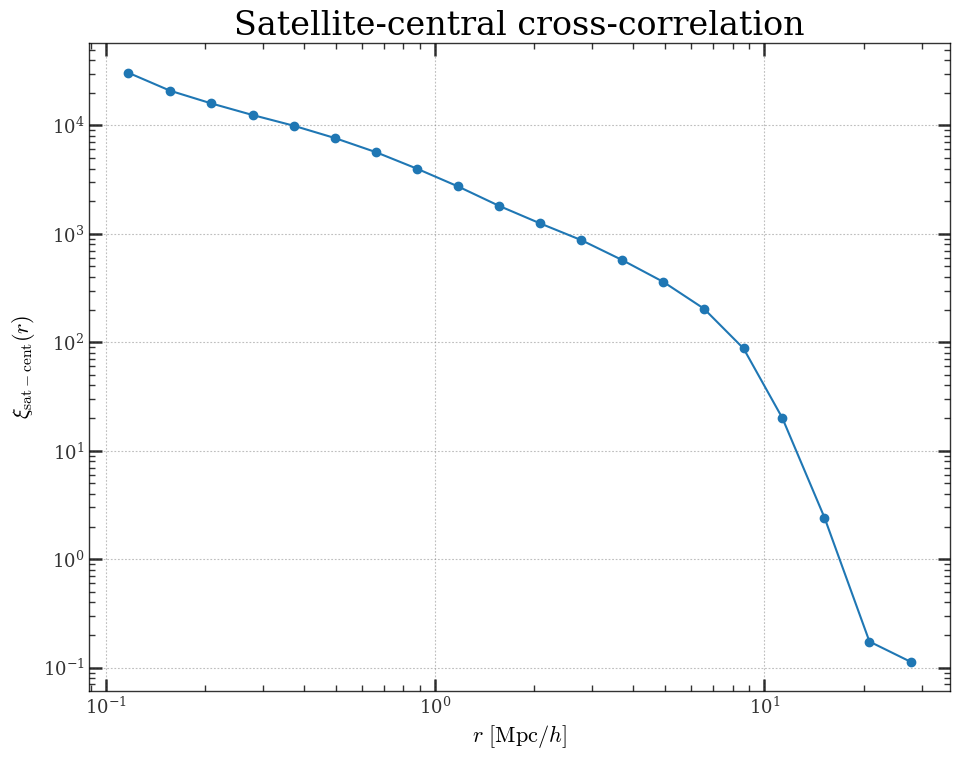

In [4]:
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'src').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root containing src/')


repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.setconfig()

from src.analysis.correlation.satellite_cross_correlation import satellite_central_cross_correlation
from src.config import get_base_dir

iz_path = Path(get_base_dir()) / 'iz155'
res = satellite_central_cross_correlation(str(iz_path), 0)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(res['r'], res['xi'], 'o-', lw=1.5)
ax.axhline(0.0, color='0.35', lw=1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$r\ [\mathrm{Mpc}/h]$')
ax.set_ylabel(r'$\xi_{\mathrm{sat-cent}}(r)$')
ax.set_title('Satellite-central cross-correlation')
fig.tight_layout()
plt.show()